In [6]:
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import os
import shutil
import random
from pathlib import Path
import numpy as np
import cv2
#data_path = r"C:\Users\USER\Downloads\im_Dyskeratotic\im_Dyskeratotic"
BASE_DIR = Path(r"C:\Users\USER\Downloads")

grupos = {
    "normal":  ["im_Superficial-Intermediate", "im_Parabasal"],
    "anormal": ["im_Dyskeratotic", "im_Koilocytotic", "im_Metaplastic"],
}

OUTPUT_DIR = Path("dataset_binario")
SPLITS = {"train": 0.7, "val": 0.15, "test": 0.15}
random.seed(42)

In [ ]:
####este codigo lo hice mejor desde Visual Studio porque lo tenia como caliz del tetra pasado, lo revivi y lo mezcle con nuevas cosas para darle una nueva vida xd

In [7]:
BASE_DIR = Path(r"C:\Users\USER\Downloads")

for carpeta in ["im_Dyskeratotic", "im_Koilocytotic", "im_Metaplastic",
                "im_Parabasal", "im_Superficial-Intermediate"]:
    ruta = BASE_DIR / carpeta / carpeta
    existe = ruta.exists()
    n_bmp = len(list(ruta.glob("*.bmp"))) if existe else 0
    print(f"{carpeta}: existe={existe}, .bmp encontrados={n_bmp}")

im_Dyskeratotic: existe=True, .bmp encontrados=223
im_Koilocytotic: existe=True, .bmp encontrados=238
im_Metaplastic: existe=True, .bmp encontrados=271
im_Parabasal: existe=True, .bmp encontrados=108
im_Superficial-Intermediate: existe=True, .bmp encontrados=126


In [ ]:
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for clase, carpetas_origen in grupos.items():
    archivos = []
    for carpeta in carpetas_origen:
        ruta = BASE_DIR / carpeta / carpeta 
        if not ruta.exists():
            print(f"No encontré {ruta}, la salto.")
            continue
        archivos += [ruta / f for f in os.listdir(ruta) if f.lower().endswith(".bmp")]

    random.shuffle(archivos)
    n = len(archivos)
    n_train = int(n * SPLITS["train"])
    n_val = int(n * SPLITS["val"])

    reparto = {
        "train": archivos[:n_train],
        "val": archivos[n_train:n_train + n_val],
        "test": archivos[n_train + n_val:],
    }

    for split, lista in reparto.items():
        destino = OUTPUT_DIR / split / clase
        destino.mkdir(parents=True, exist_ok=True)
        for archivo in lista:
            shutil.copy2(archivo, destino / archivo.name)

    print(f"{clase}: {n} imágenes -> train={len(reparto['train'])}, val={len(reparto['val'])}, test={len(reparto['test'])}")


normal: 234 imágenes -> train=163, val=35, test=36
anormal: 732 imágenes -> train=512, val=109, test=111


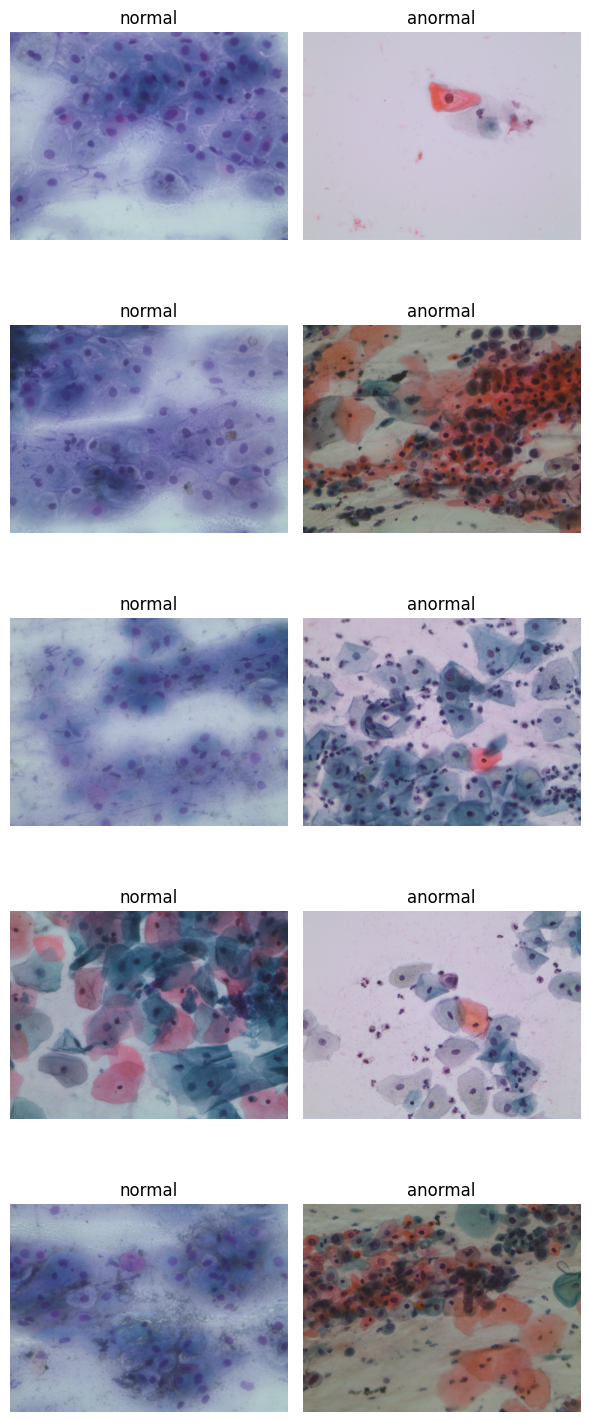

In [10]:
import cv2
normales = []
anormales = []
for f in os.listdir(OUTPUT_DIR / "train" / "normal")[:5]:
    img = cv2.imread(str(OUTPUT_DIR / "train" / "normal" / f))
    normales.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

for f in os.listdir(OUTPUT_DIR / "train" / "anormal")[:5]:
    img = cv2.imread(str(OUTPUT_DIR / "train" / "anormal" / f))
    anormales.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

fig, axes = plt.subplots(5, 2, figsize=(6, 15))

for i in range(5):
    axes[i, 0].imshow(normales[i])
    axes[i, 0].set_title("normal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(anormales[i])
    axes[i, 1].set_title("anormal")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("muestras_dataset.png", dpi=200, bbox_inches="tight")
plt.show()

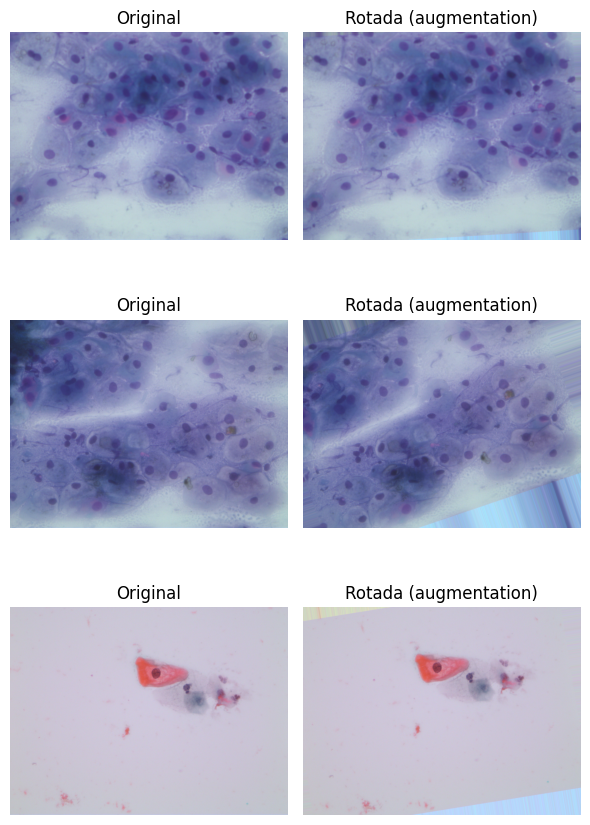

In [ ]:
import numpy as np

rotate_gen = ImageDataGenerator(rotation_range=25)

ejemplos_rot = [normales[0], normales[1], anormales[0]] 

fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i, img in enumerate(ejemplos_rot):
    img_arr = img.astype(np.float32)
    img_rotada = rotate_gen.random_transform(img_arr).astype(np.uint8)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(img_rotada)
    axes[i, 1].set_title("Rotada (augmentation)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.savefig("ejemplo_rotacion.png", dpi=200, bbox_inches="tight")
plt.show()

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "dataset_binario/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_directory(
    "dataset_binario/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_gen = val_datagen.flow_from_directory(
    "dataset_binario/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("Mapeo de clases:", train_gen.class_indices)


Found 367 images belonging to 2 classes.
Found 128 images belonging to 2 classes.
Found 129 images belonging to 2 classes.
Mapeo de clases: {'anormal': 0, 'normal': 1}


In [14]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [15]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)


e:\Python\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.6730 - loss: 0.6888 - precision: 0.4683 - recall: 0.6101 - val_accuracy: 0.8750 - val_loss: 0.2924 - val_precision: 0.8947 - val_recall: 0.5484
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8586 - loss: 0.3154 - precision: 0.7979 - recall: 0.7625 - val_accuracy: 0.8828 - val_loss: 0.2461 - val_precision: 0.8333 - val_recall: 0.6452
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9216 - loss: 0.2032 - precision: 0.8566 - recall: 0.8923 - val_accuracy: 0.8906 - val_loss: 0.2319 - val_precision: 0.9048 - val_recall: 0.6129
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9322 - loss: 0.1829 - precision: 0.9083 - recall: 0.8558 - val_accuracy: 0.9062 - val_loss: 0.2136 - val_precision: 0.8800 - val_recall: 0.7097
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9526 - loss: 0.1550 - precision: 0.9248 - recall: 0.9074 - val_accuracy: 0.8984 - val_loss: 0.2040 - val

In [16]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

history_ft = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)


Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8727 - loss: 0.2934 - precision_1: 0.8418 - recall_1: 0.7746 - val_accuracy: 0.9297 - val_loss: 0.1654 - val_precision_1: 0.8235 - val_recall_1: 0.9032
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8743 - loss: 0.2722 - precision_1: 0.8556 - recall_1: 0.7346 - val_accuracy: 0.9297 - val_loss: 0.1994 - val_precision_1: 0.7895 - val_recall_1: 0.9677
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9194 - loss: 0.2067 - precision_1: 0.8849 - recall_1: 0.8541 - val_accuracy: 0.9141 - val_loss: 0.2409 - val_precision_1: 0.7500 - val_recall_1: 0.9677
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9133 - loss: 0.1986 - precision_1: 0.8479 - recall_1: 0.8697 - val_accuracy: 0.9219 - val_loss: 0.2744 - val_precision_1: 0.7561 - val_recall_1: 1.0000
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9049 - loss: 0.2074 - precision_1: 0.8246 - recall_1: 0.8682 - val_accur

In [17]:
preds = model.predict(test_gen)
y_pred = (preds > 0.5).astype(int)

y_true = test_gen.classes

print("Mapeo de clases:", test_gen.class_indices)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step 
Mapeo de clases: {'anormal': 0, 'normal': 1}
[[81 15]
 [ 1 32]]
              precision    recall  f1-score   support

     anormal       0.99      0.84      0.91        96
      normal       0.68      0.97      0.80        33

    accuracy                           0.88       129
   macro avg       0.83      0.91      0.86       129
weighted avg       0.91      0.88      0.88       129



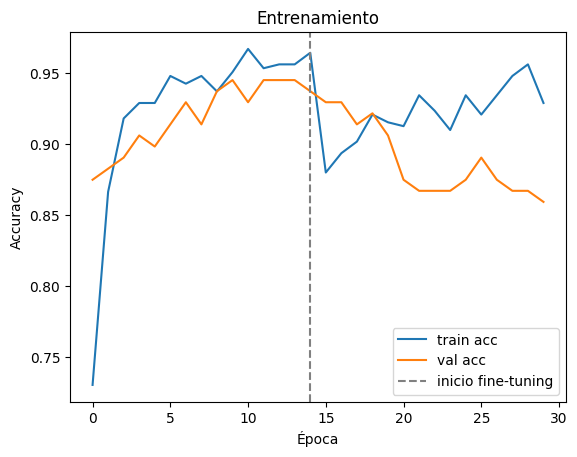

In [18]:
acc = history.history['accuracy'] + history_ft.history['accuracy']
val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']

plt.plot(acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.axvline(x=len(history.history['accuracy']) - 1, color='gray', linestyle='--', label='inicio fine-tuning')
plt.legend()
plt.title("Entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.show()

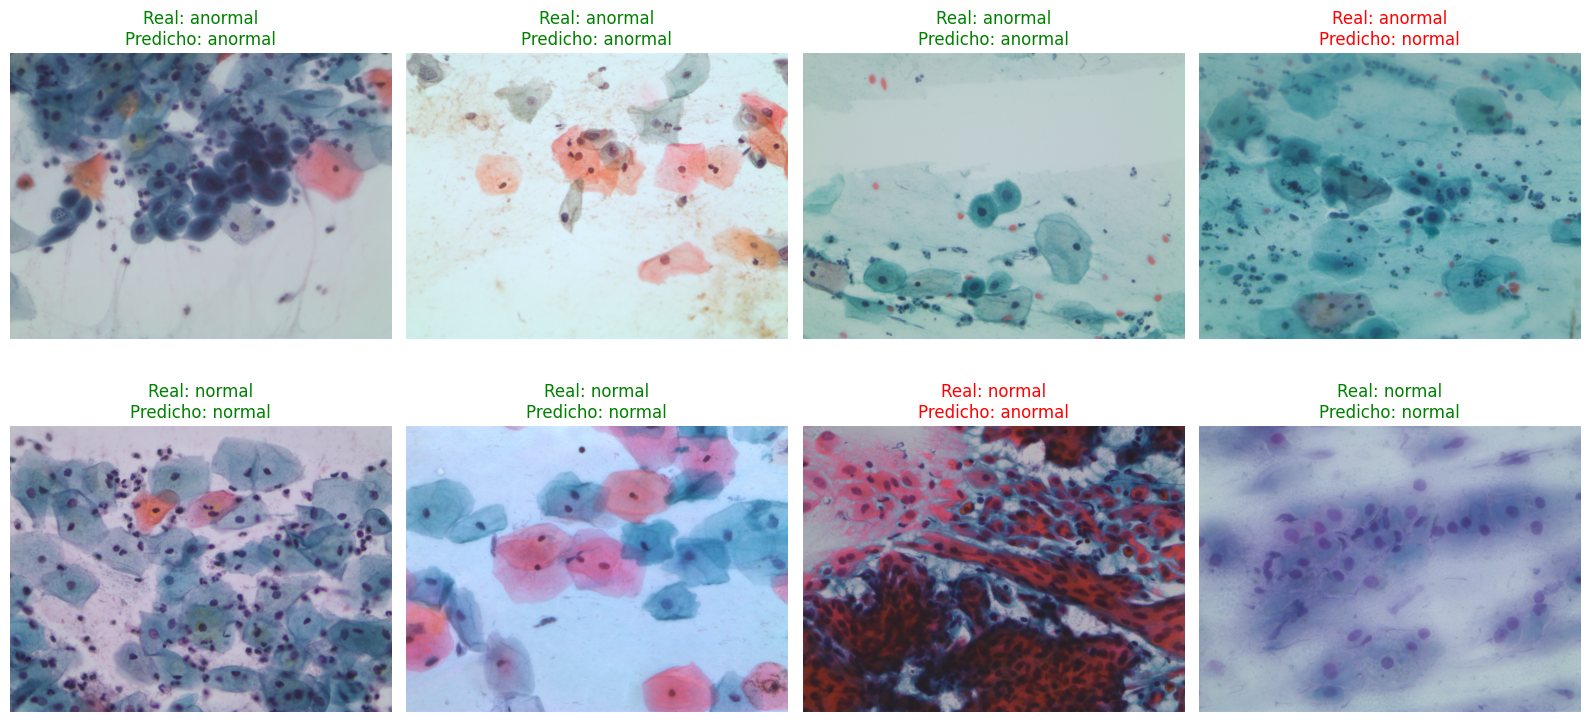

In [ ]:
import random

idx_to_class = {v: k for k, v in test_gen.class_indices.items()}

n_ejemplos = 8
random.seed(1) 
indices = random.sample(range(len(test_gen.filepaths)), n_ejemplos)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for ax, idx in zip(axes, indices):
    img_path = test_gen.filepaths[idx]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    real = idx_to_class[y_true[idx]]
    predicho = idx_to_class[y_pred[idx][0]]
    correcto = real == predicho

    ax.imshow(img)
    ax.set_title(f"Real: {real}\nPredicho: {predicho}", color="green" if correcto else "red")
    ax.axis("off")

plt.tight_layout()
plt.savefig("ejemplos_backtest.png", dpi=200, bbox_inches="tight")
plt.show()

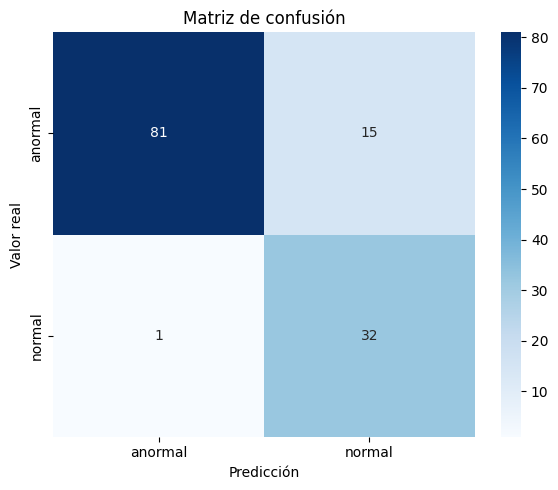

In [20]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
labels = list(test_gen.class_indices.keys())

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.savefig("matriz_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
model.save("modelo_celulas_cervicales.h5")
print("Modelo guardado.")#guardarlo por si acaso xd